# Architectural Experimental Validation: CS-01 TAS

**Purpose**: drive a FastAPI microservice replication of the TAS topology
at the **seeded operating point** for each adaptation and report the
measured behaviour. This notebook is the prototype-side execution; the
analytic / dimensional / stochastic comparison lives in
`07-comparison.ipynb`.

This is the **fixed-point** sibling of `06-yoly-experimental.ipynb`:
one (mu, c, K) operating point per adaptation, lambda ramped to
saturation, no design-grid sweep. For the configuration-sweep variant
(yoly-style cloud across the (mu_factor, c, K) grid measured on the
prototype), use `06-yoly-experimental.ipynb`.

**Not a goal**: reproducing Weyns & Calinescu's published ReSeP/Java
numbers. Different stack means different absolute numbers; DASA's claim is
that **dimensionally-normalised coefficients** match.

## Design

- 13 FastAPI services (6 composite TAS + 7 atomic MAS/AS/DS) wired by a
  shared httpx client through in-process ASGI transport.
- Poisson client at `TAS_{1}` with Exp interarrival; lambda ramps from
  `lambda_start_frac * lambda_z` to `lambda_z` in `lambda_steps` increments,
  with first-cascade early stop.
- Four adaptations map to four composite patterns:
  - `baseline` -> **NoAdapt** (single invocation, fail on 5xx)
  - `s1` -> **Retry** (sequential on failure; service-failure adaptation)
  - `s2` -> **ParallelRedundant** (fire all equivalents, first-success wins)
  - `aggregate` -> **Retry + ParallelRedundant**
- All knobs (mu, eps, c, K) come from `data/config/profile/<dflt|opti>.json`;
  only deployment plumbing (ports, ramp) lives in
  `data/config/method/experiment.json`.

Outputs go to `data/results/experiment/<scenario>/<profile>.json` plus
per-service invocation CSVs.

In [1]:
import nest_asyncio

%matplotlib inline

from pathlib import Path

import pandas as pd

from src.io import load_method_cfg
from src.methods.experiment import run as run_experiment
from src.view import (
    plot_qn_topology,
    plot_node_heatmap,
    plot_node_diffmap,
    plot_arch_bars,
    plot_arch_delta,
)

nest_asyncio.apply()

_IMG_ROOT = Path("data/img/experiment")
_ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# notebook-runtime override of the canonical experiment config: smaller
# rate schedule + tighter probe windows so the 4-adaptation ramp completes
# in a few minutes instead of ~30. The CLI still uses the full config.
_NB_METHOD_CFG = load_method_cfg("experiment")
_NB_METHOD_CFG["ramp"] = {
    "min_samples_per_kind": 32,
    "max_probe_window_s": 10.0,
    "rates": [50, 100, 200, 300, 500],
    "cascade": {"mode": "rolling", "threshold": 0.10, "window": 50},
}

# human-readable scenario labels for plot titles / legends. `aggregate`
# is the fully-adapted configuration (opti routing + opti services at
# the three swap slots) so it is labelled "After Adaptation"
_DISPLAY = {
    "baseline": "Before Adaptation",
    "s1": "S1: Service-Failure Adapt.",
    "s2": "S2: Response-Time Adapt.",
    "aggregate": "After Adaptation",
}

## 1. Run the experiment on every adaptation

`run_experiment(adp=a, wrt=True)` loads the resolved `NetCfg`, spins up
the 13-service mesh in-process, drives a sample-count ramp through
`TAS_{1}`, collects per-service CSV logs, writes the per-run envelope
under `data/results/experiment/<adaptation>/`, and returns the per-node
+ aggregate DataFrames plus the R1 / R2 / R3 verdict. Each rate in the
ramp sends until every request kind has `min_samples_per_kind` (>= 32)
completions, then steps to the next rate. The ramp halts when the
cascade rule (rolling infra-failure window or fail-fast) trips.

*Tip*: for fast iteration during development, tune `ramp.rates` or drop
`min_samples_per_kind` down to the CLT floor in
`data/config/method/experiment.json`.

In [2]:
_results = {_a: run_experiment(adp=_a, wrt=True,
                               method_cfg=_NB_METHOD_CFG)
            for _a in _ADAPTATIONS}

# unpack the per-adaptation pieces used in every later cell (mirrors 01-analytic.ipynb)
_cfgs = {_a: _results[_a]["config"] for _a in _ADAPTATIONS}
_nodes = {_a: _results[_a]["nodes"] for _a in _ADAPTATIONS}
_nets = {_a: _results[_a]["network"] for _a in _ADAPTATIONS}
_reqs = {_a: _results[_a]["requirements"] for _a in _ADAPTATIONS}

print(f"Ran {len(_results)} adaptations; wrote JSONs under data/results/experiment/")

Ran 4 adaptations; wrote JSONs under data/results/experiment/


## 2. Network-wide summary

One row per adaptation: headline measured metrics (response time, utilisation, queue length).

In [3]:
_rows = []
for _a in _ADAPTATIONS:
    _n = _nets[_a].iloc[0]
    _rows.append({
        "adaptation": _a,
        "profile": _cfgs[_a].profile,
        "W_net (ms)": _n["W_net"] * 1000,
        "avg_rho": _n["avg_rho"],
        "max_rho": _n["max_rho"],
        "L_net": _n["L_net"],
    })
_summary = pd.DataFrame(_rows).set_index("adaptation")
_summary.round(4)

,profile,W_net (ms),avg_rho,max_rho,L_net
adaptation,,,,,
baseline,dflt,2.8303,0.0344,0.0787,1.2874
s1,opti,3.3253,0.0363,0.0832,1.4182
s2,opti,2.6804,0.0351,0.0787,1.3451
aggregate,opti,3.4658,0.0314,0.0541,1.3105


## 3. Per-node snapshot (baseline)

The reference configuration before any adaptation kicks in. `rho = lambda / (c * mu)` (PASTA-sampled from `c_used_at_start`); `W`, `Wq` are in seconds; `L`, `Lq` are mean request counts.

In [4]:
_nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,94.0864,250.0,4,10,0.0464,0.1971,0.0025
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,66.9728,250.0,4,10,0.0389,0.1559,0.0028
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,45.6528,250.0,4,10,0.0308,0.1234,0.0030
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,28.2723,180.0,1,10,0.0781,0.1287,0.0051
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,22.4788,250.0,3,10,0.0176,0.0530,0.0026
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,26.1866,150.0,1,10,0.0787,0.0858,0.0045
6,AS_{1},Alarm Service 1,M/M/s/K,14.1361,250.0,3,10,0.0123,0.0370,0.0030
7,AS_{2},Alarm Service 2,M/M/s/K,18.5392,250.0,2,10,0.0271,0.0543,0.0030
8,AS_{3},Alarm Service 3,M/M/s/K,18.0757,250.0,8,10,0.0048,0.0385,0.0027
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,57.4715,250.0,4,10,0.0335,0.1343,0.0024


## 4. Queue-network topology (architecture view)

Nodes are coloured by measured `rho` (cool = low, warm = high). Edge labels show routing probabilities. One topology figure per adaptation under `data/img/experiment/<adp>/topology.png`.

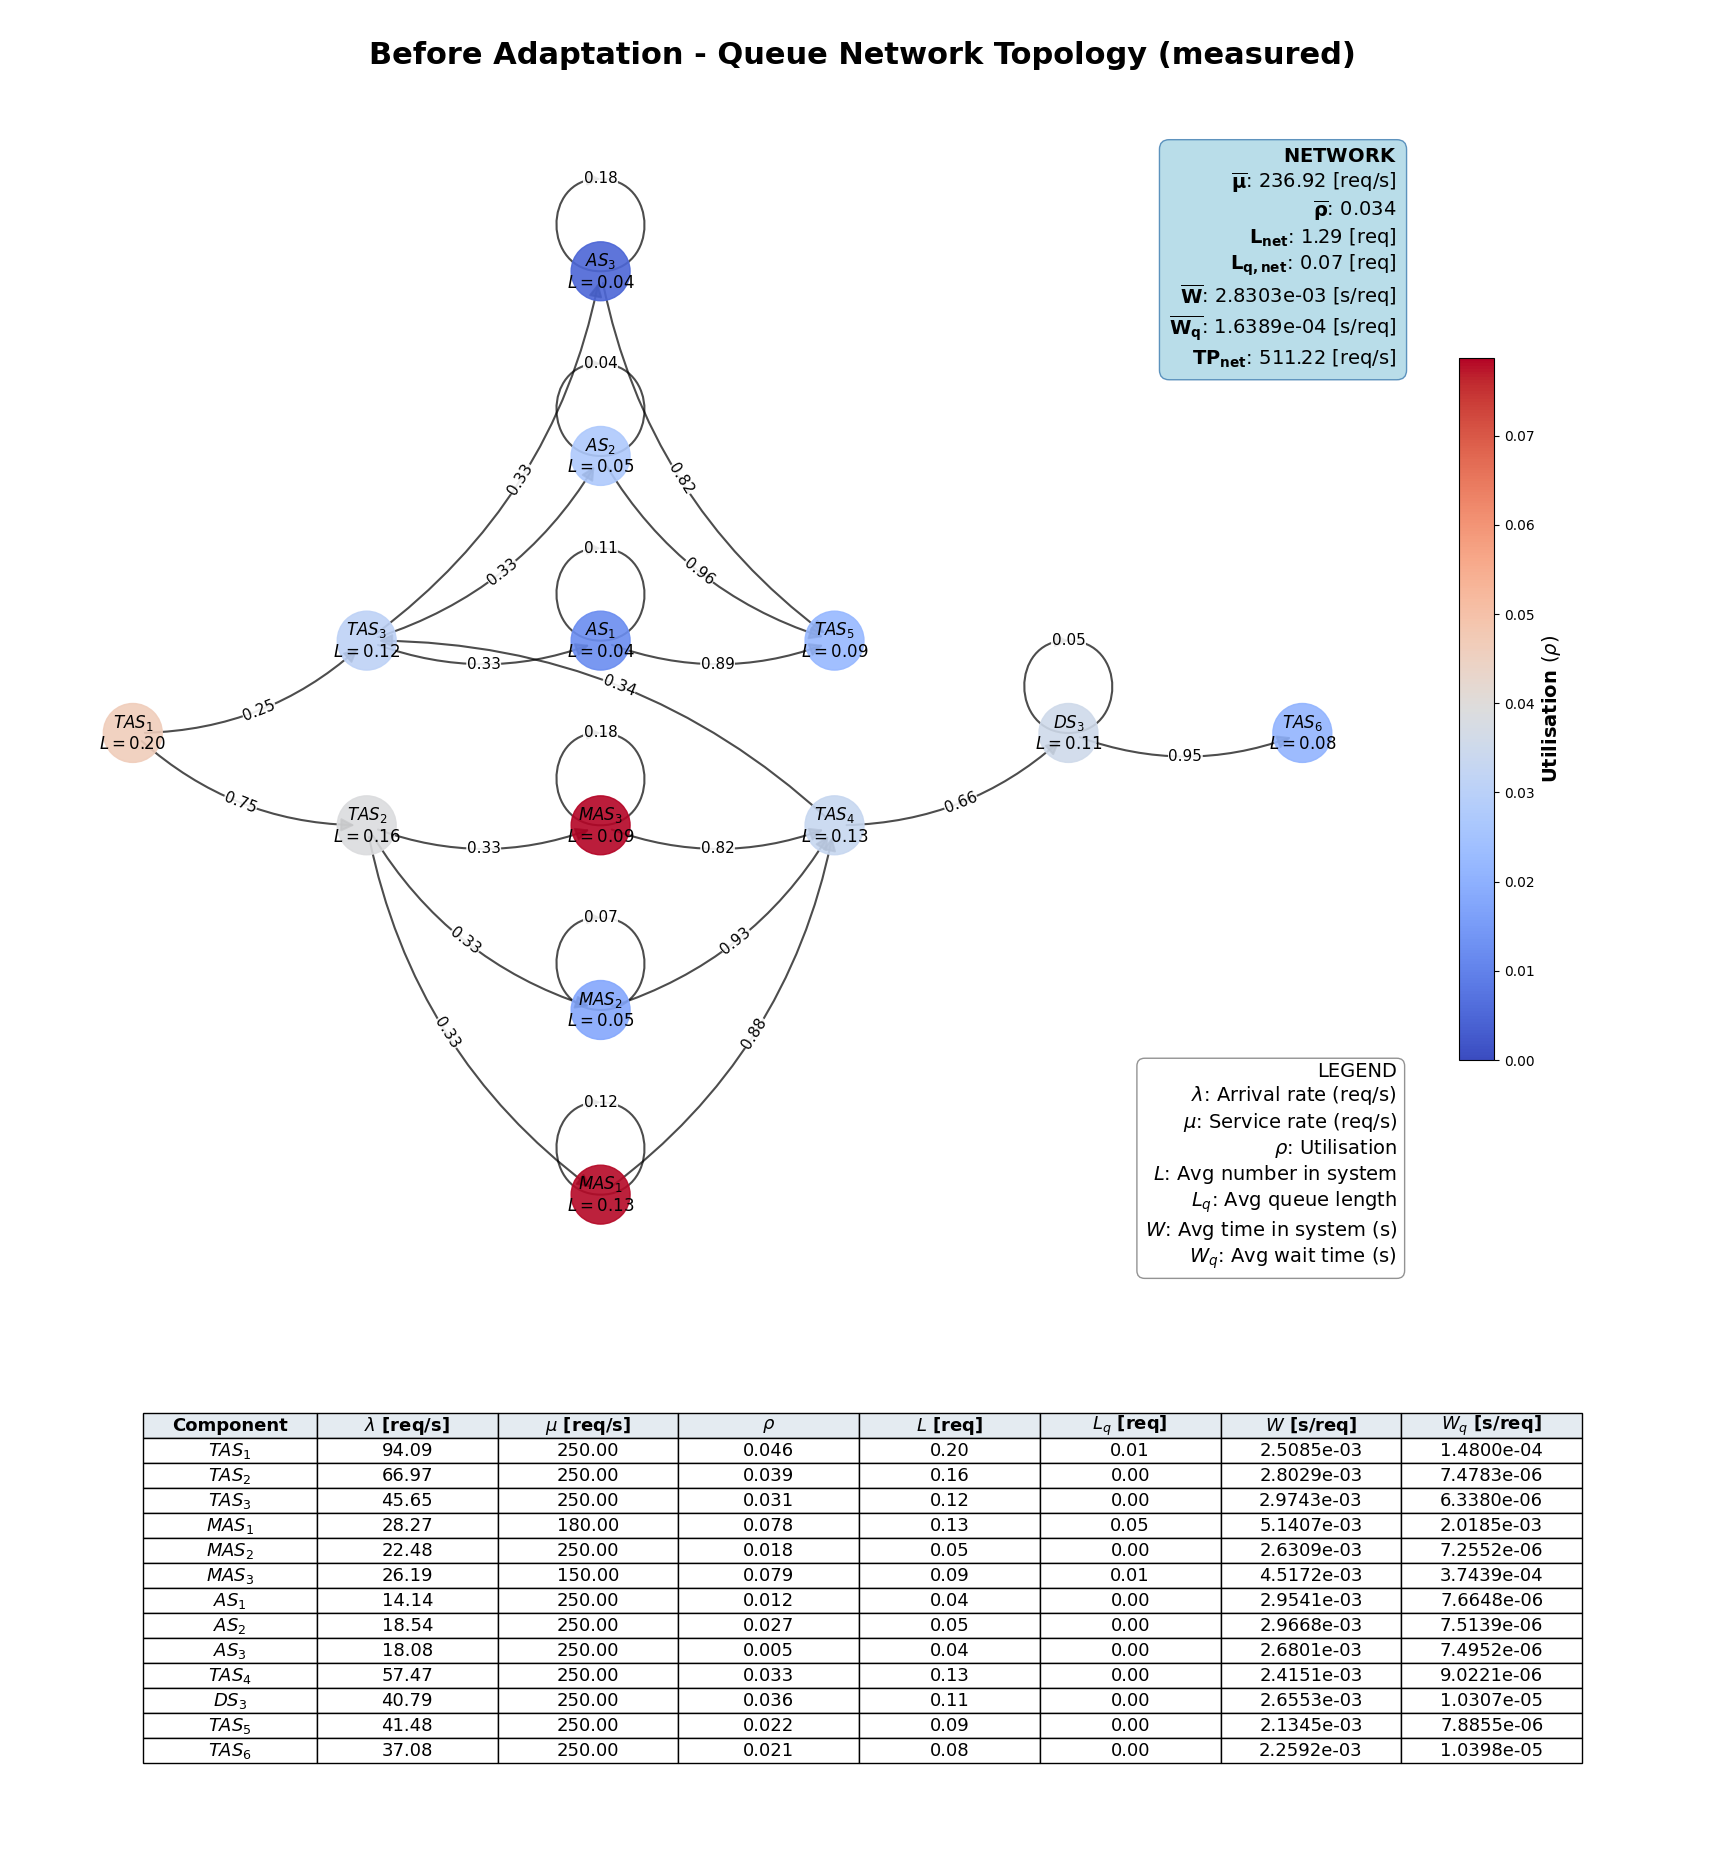

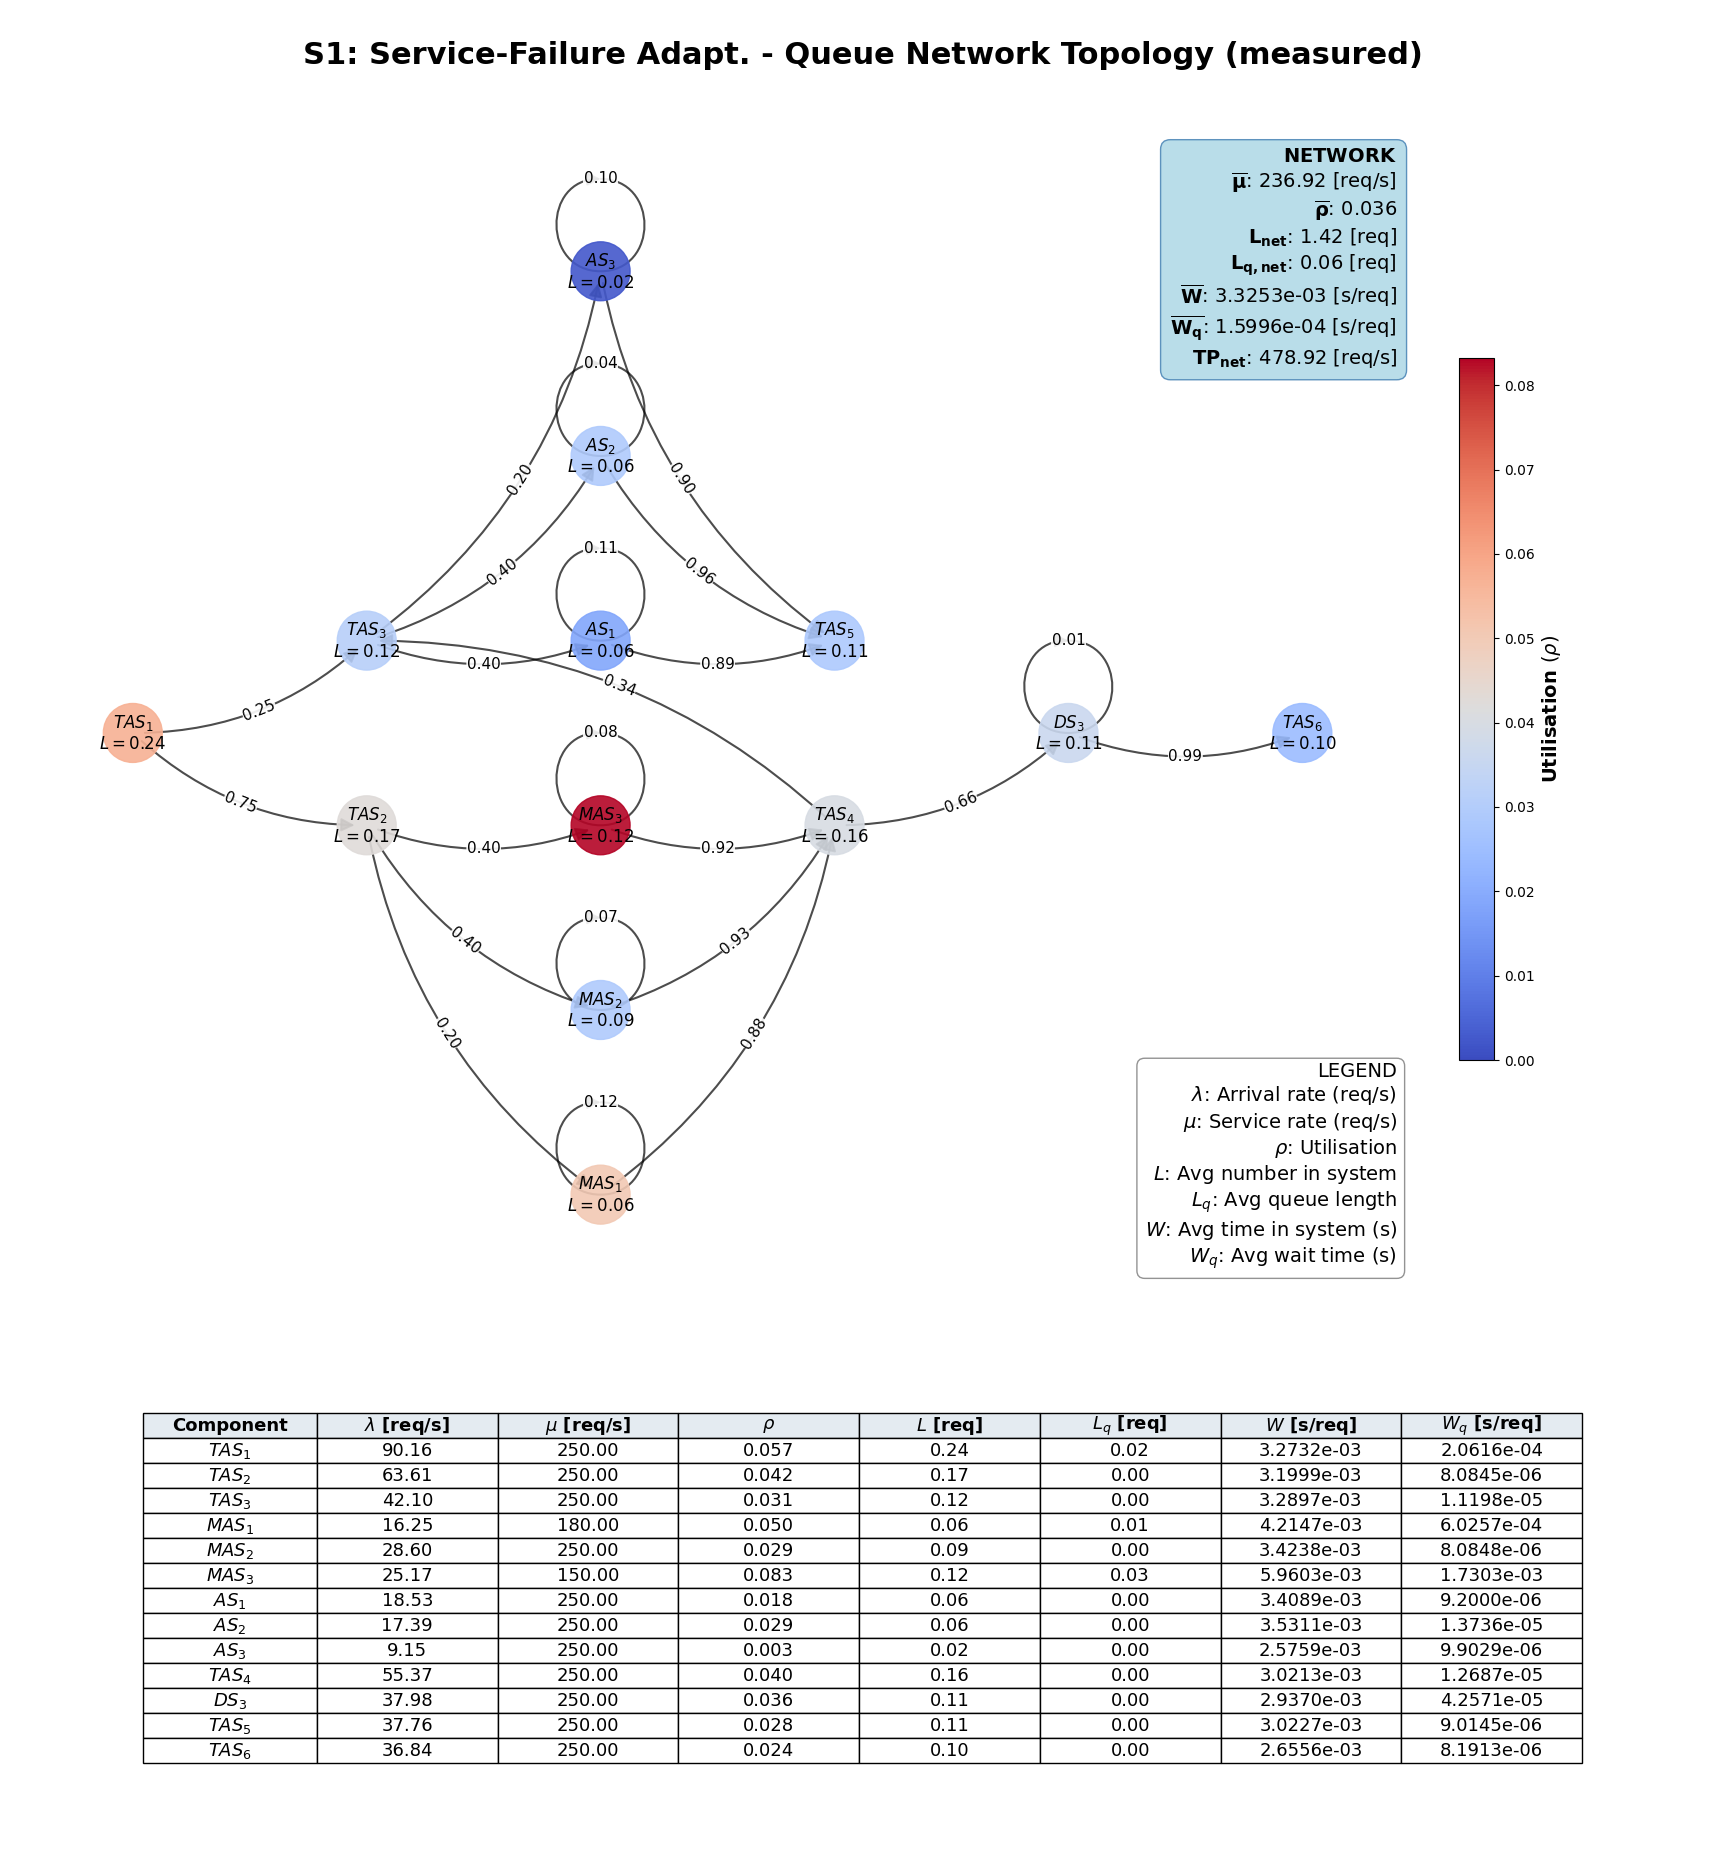

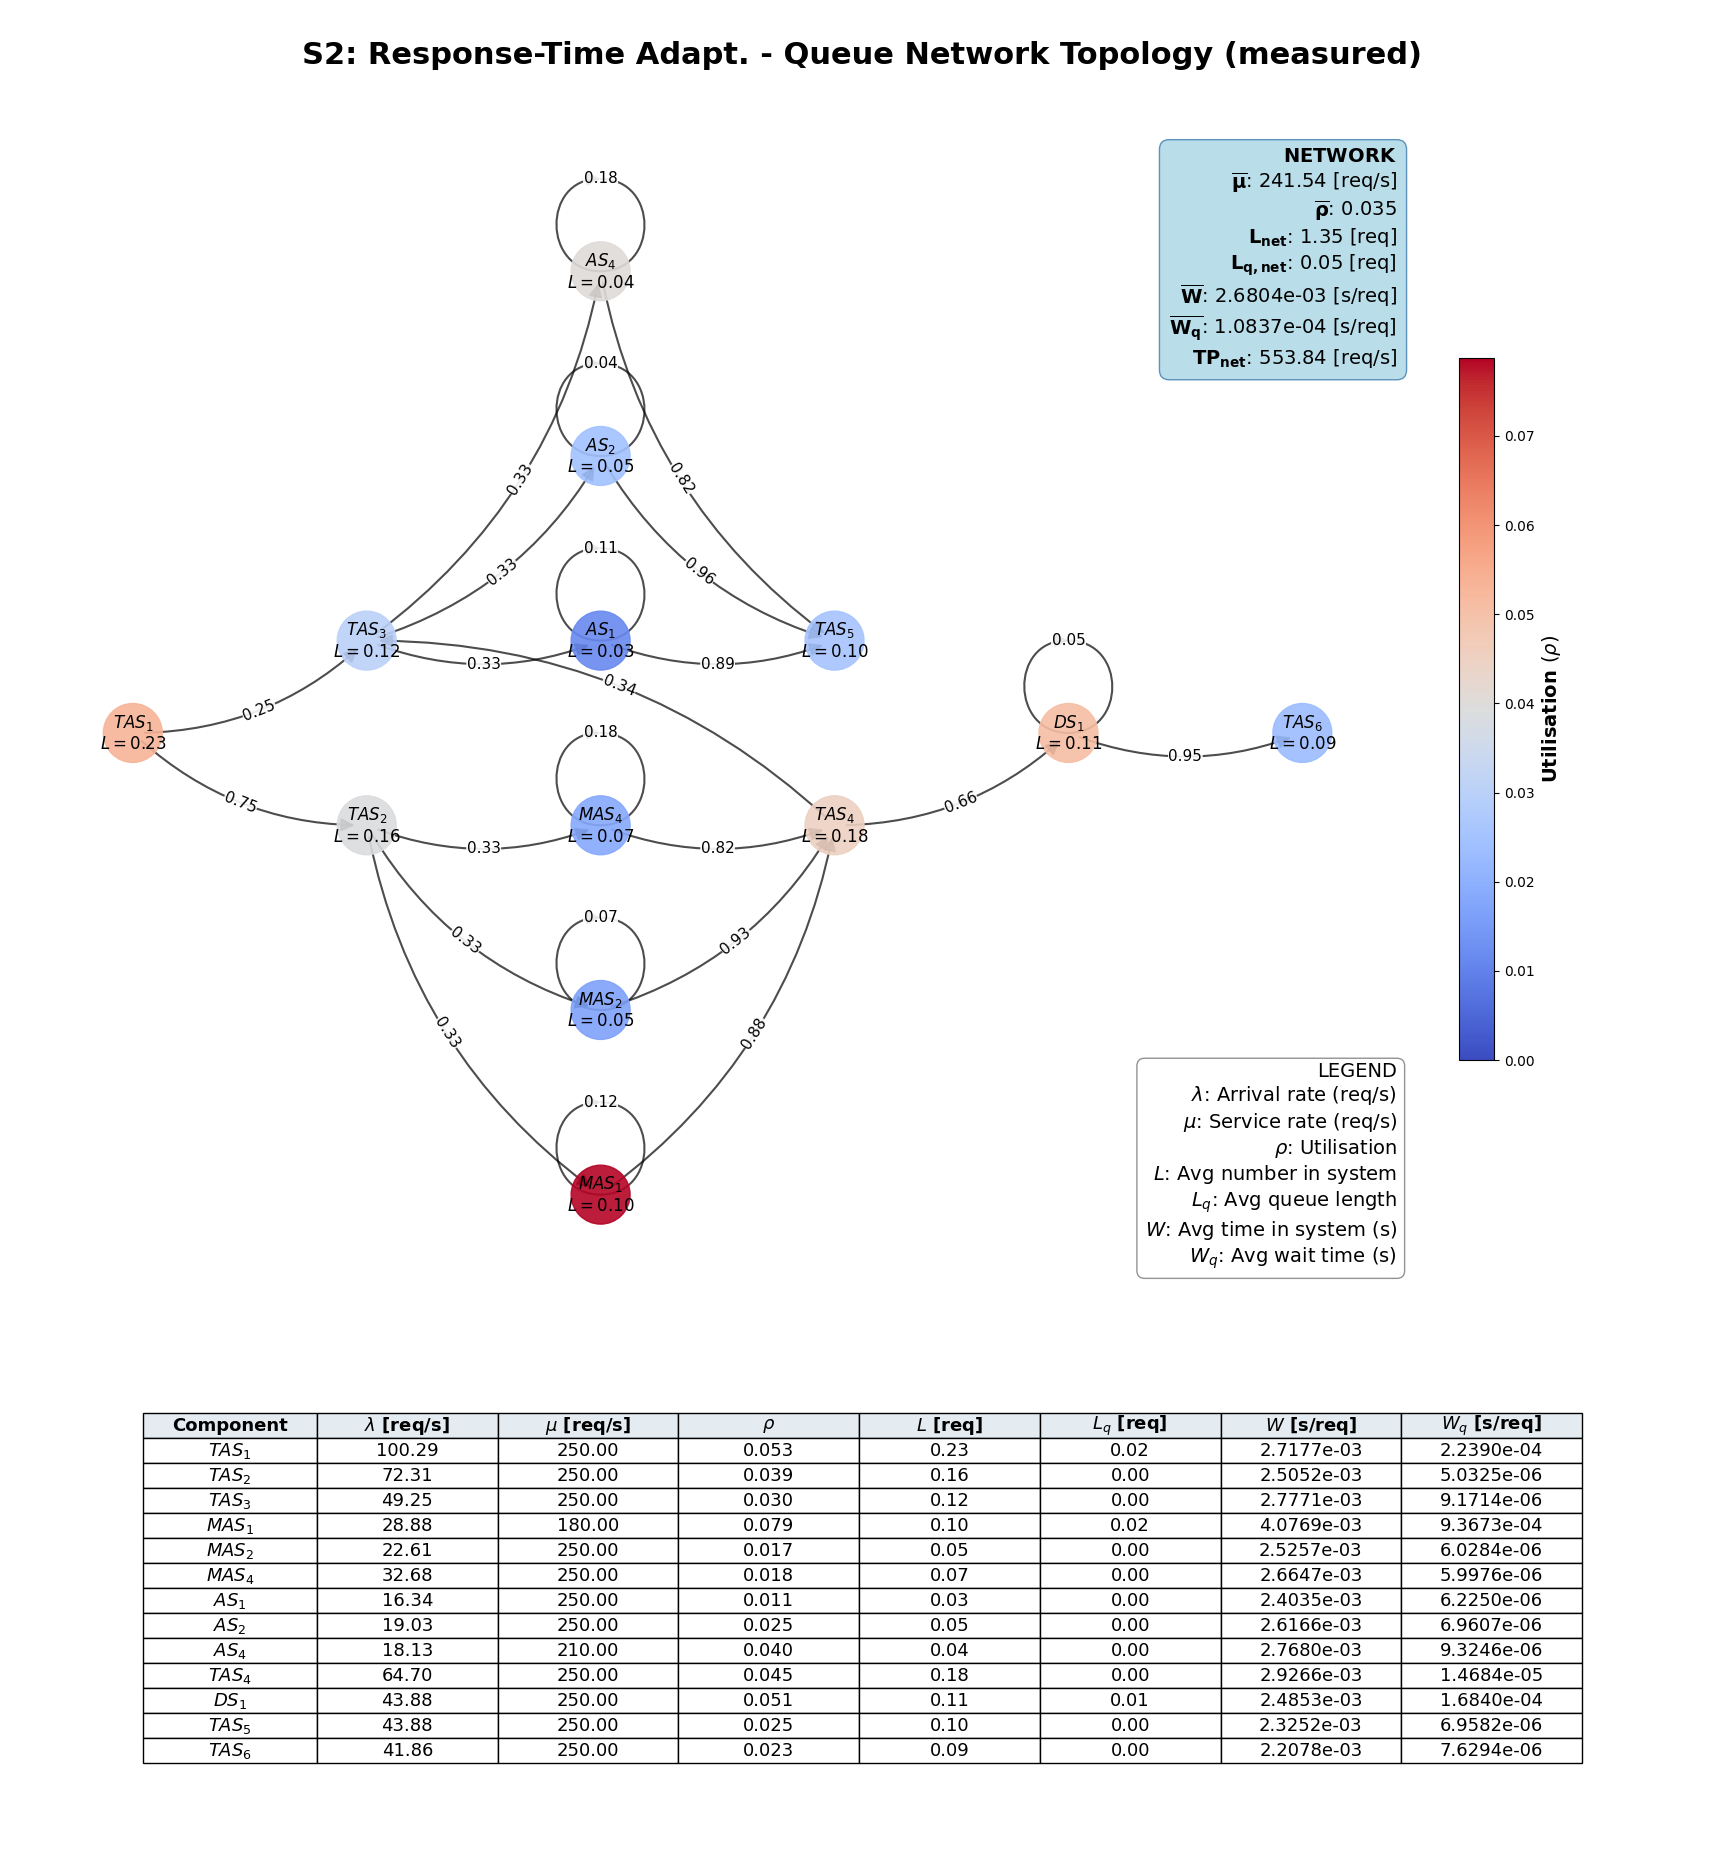

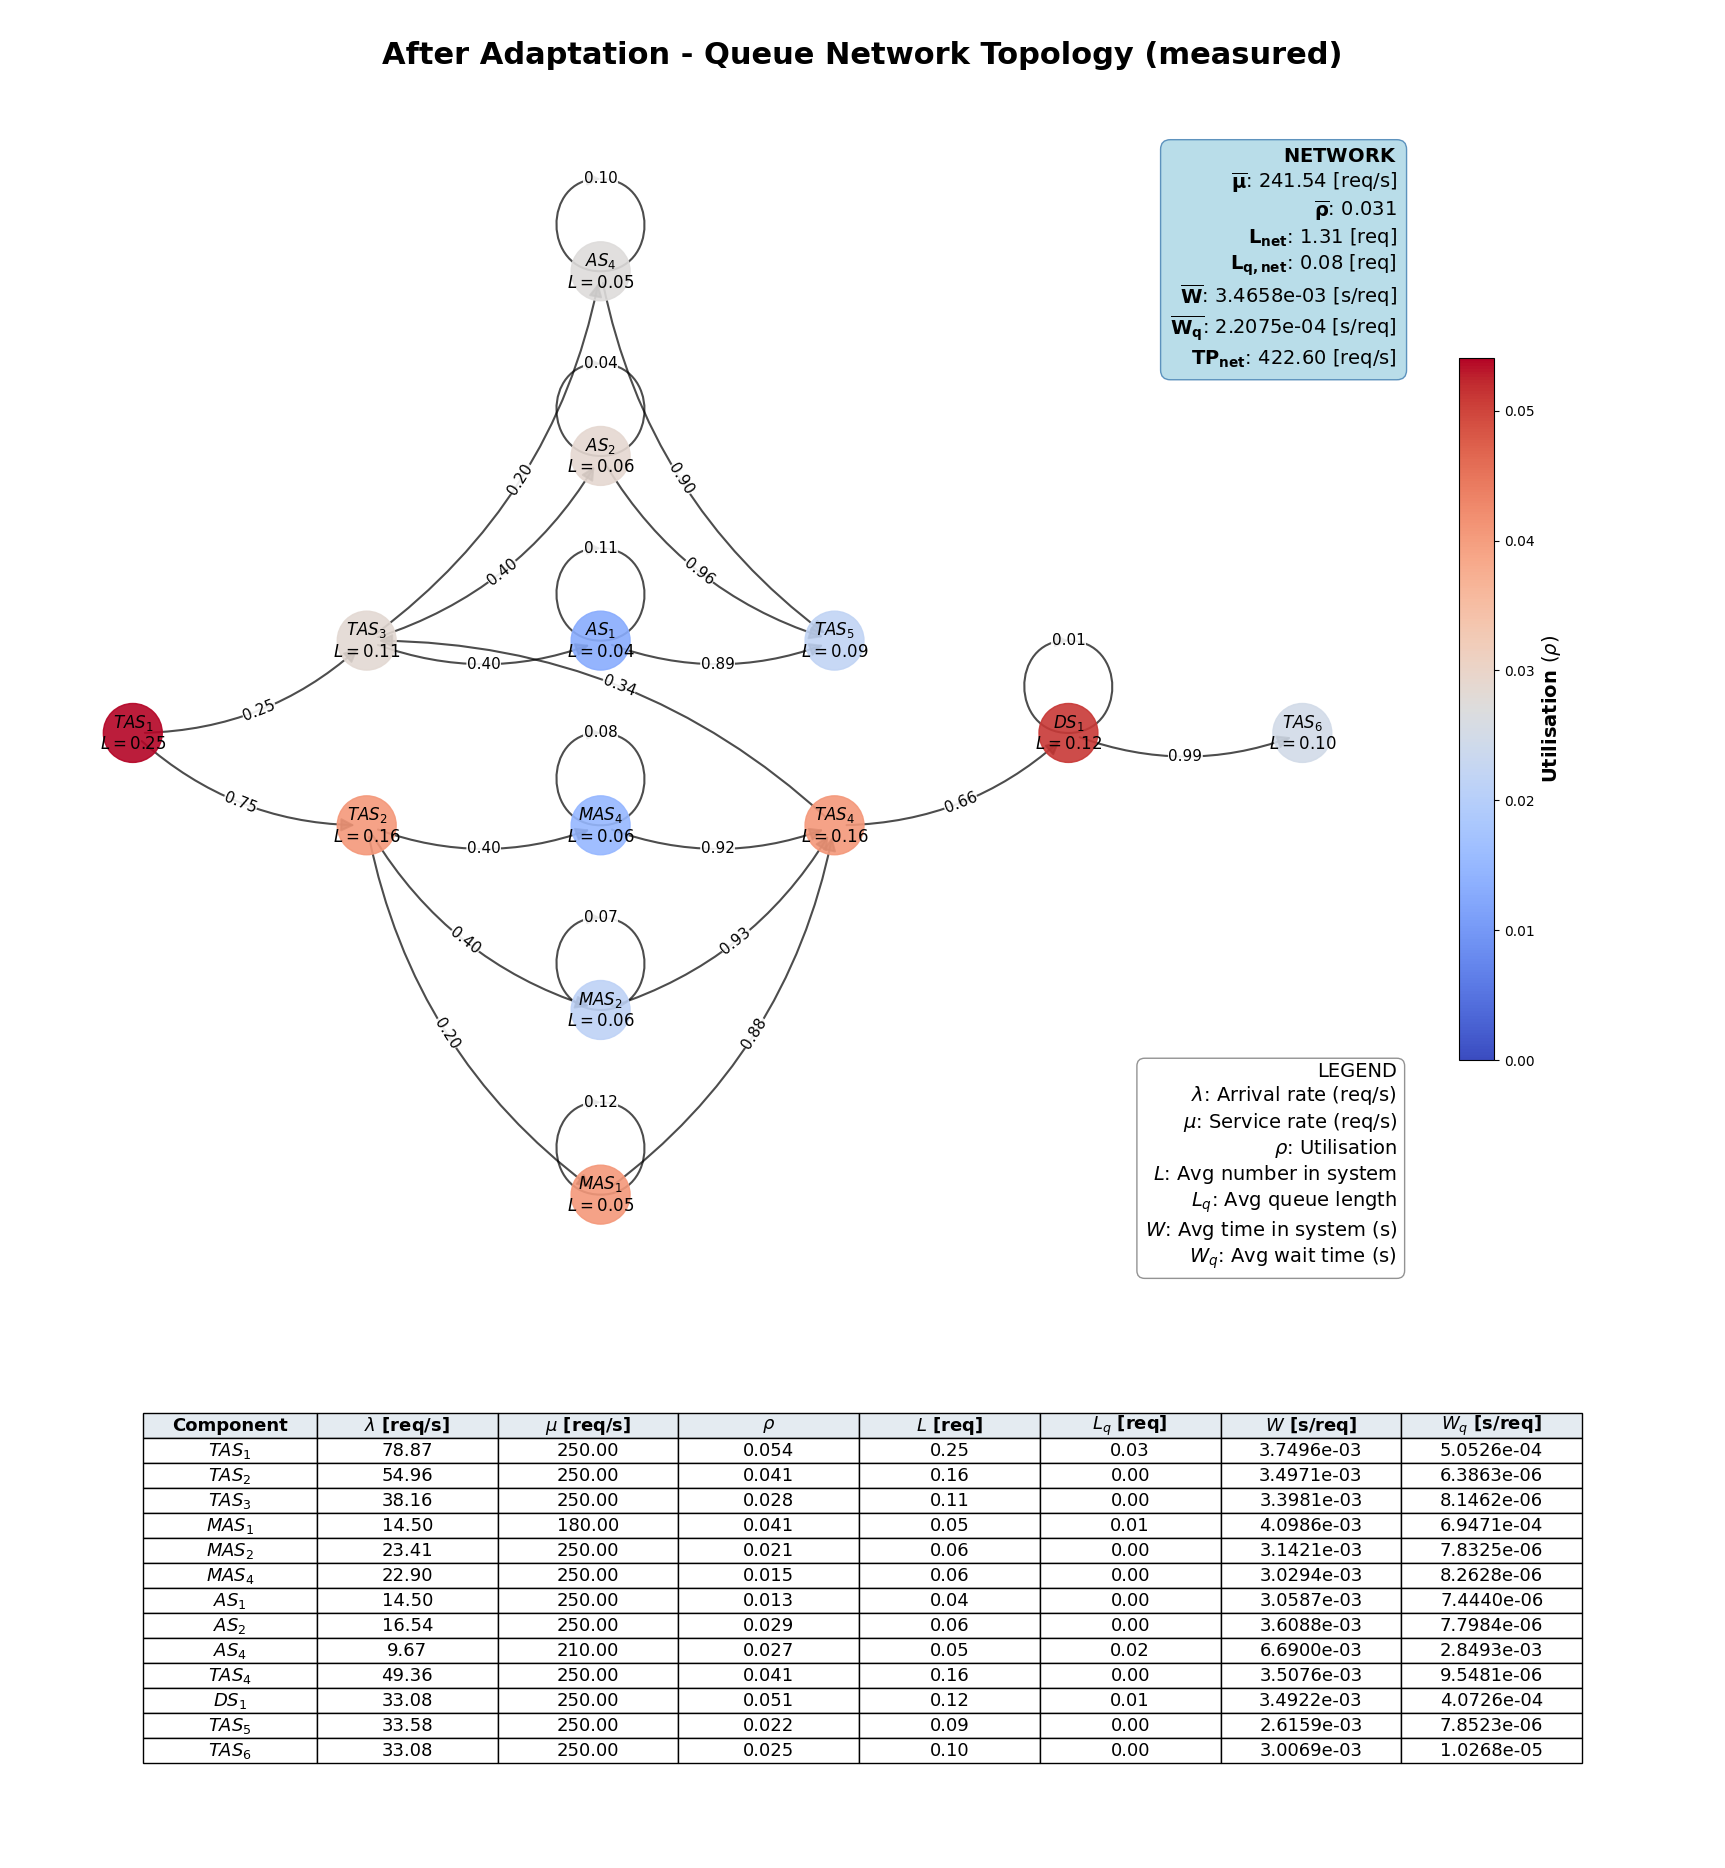

In [5]:
for _a in _ADAPTATIONS:
    plot_qn_topology(
        routs=_cfgs[_a].routing,
        ndss=_nodes[_a],
        nets=_nets[_a],
        title=f"{_DISPLAY[_a]} - Queue Network Topology (measured)",
        file_path=str(_IMG_ROOT / _a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one measured metric. Columns are normalised per-metric across both scenarios so the heat value is directly comparable. Numeric cell labels show the raw value.

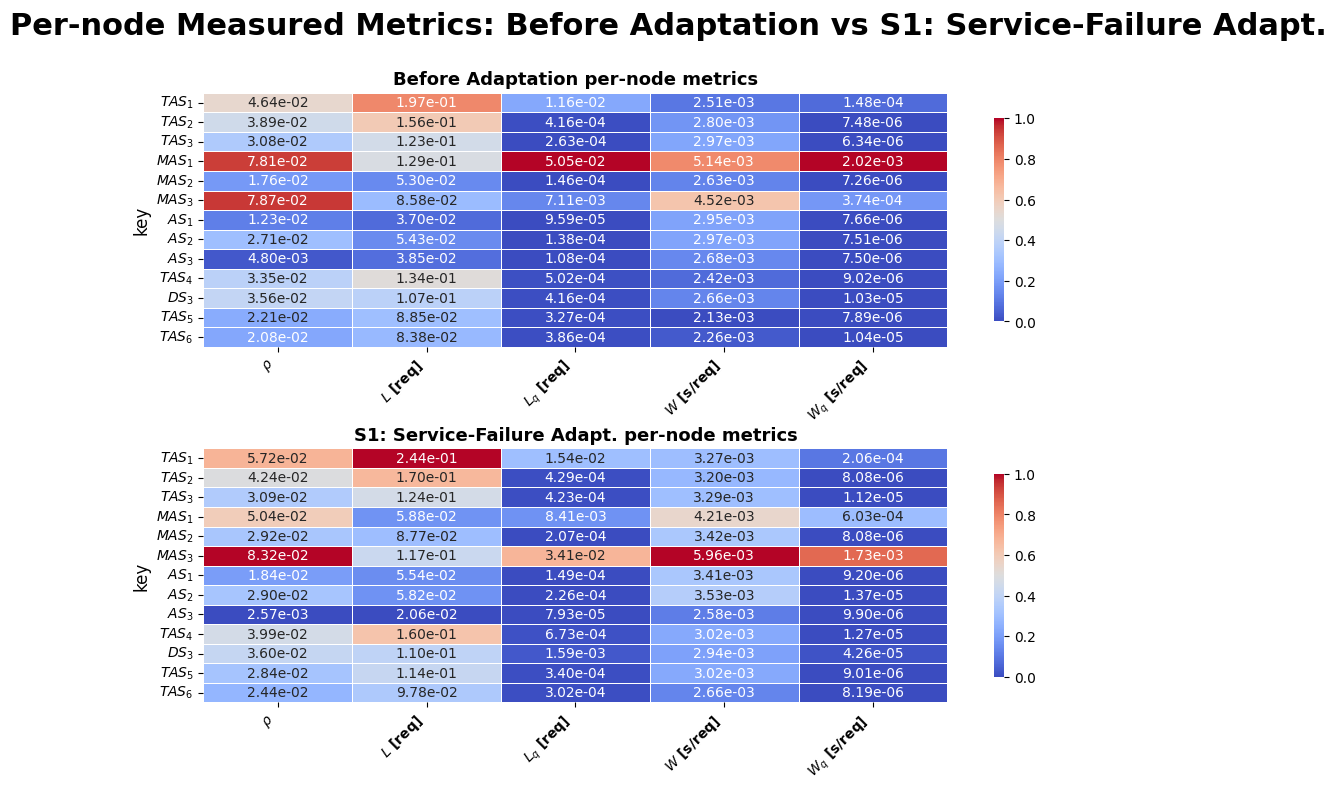

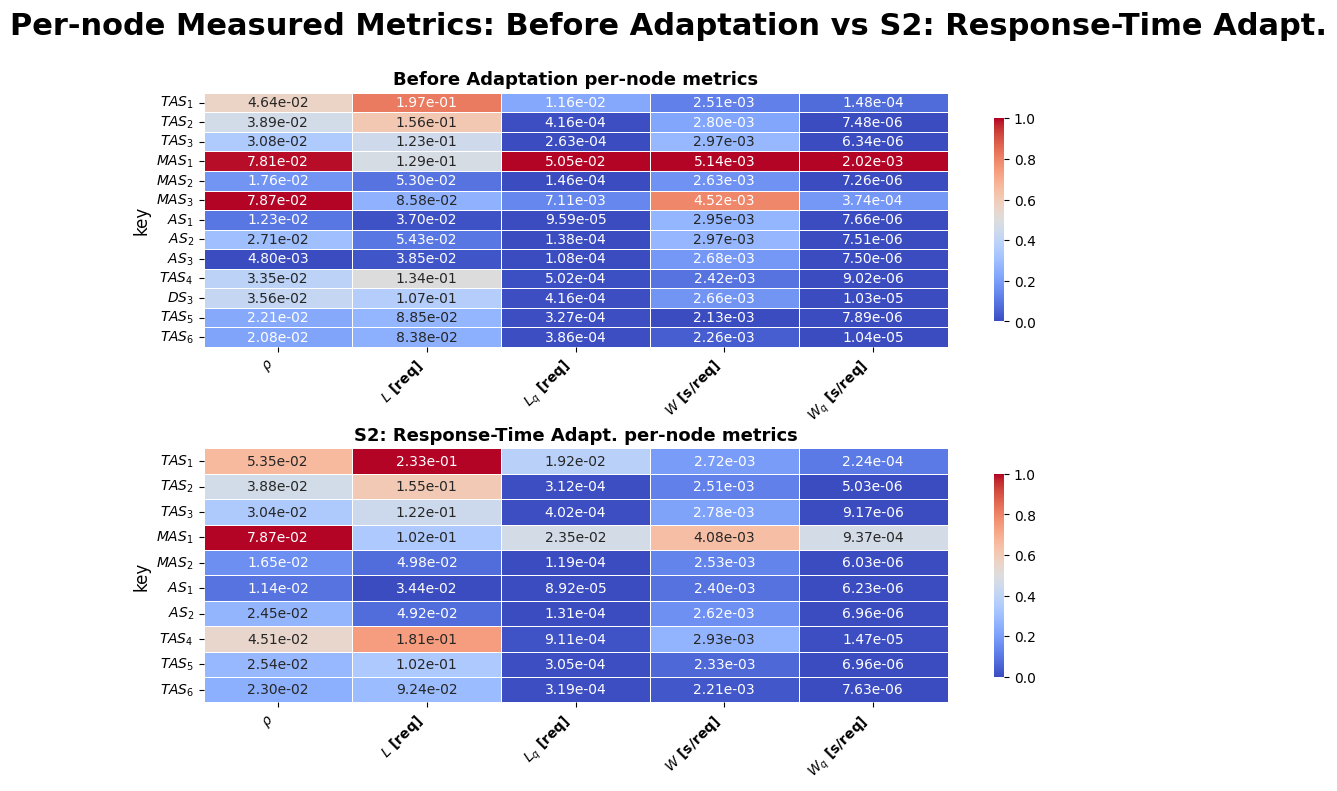

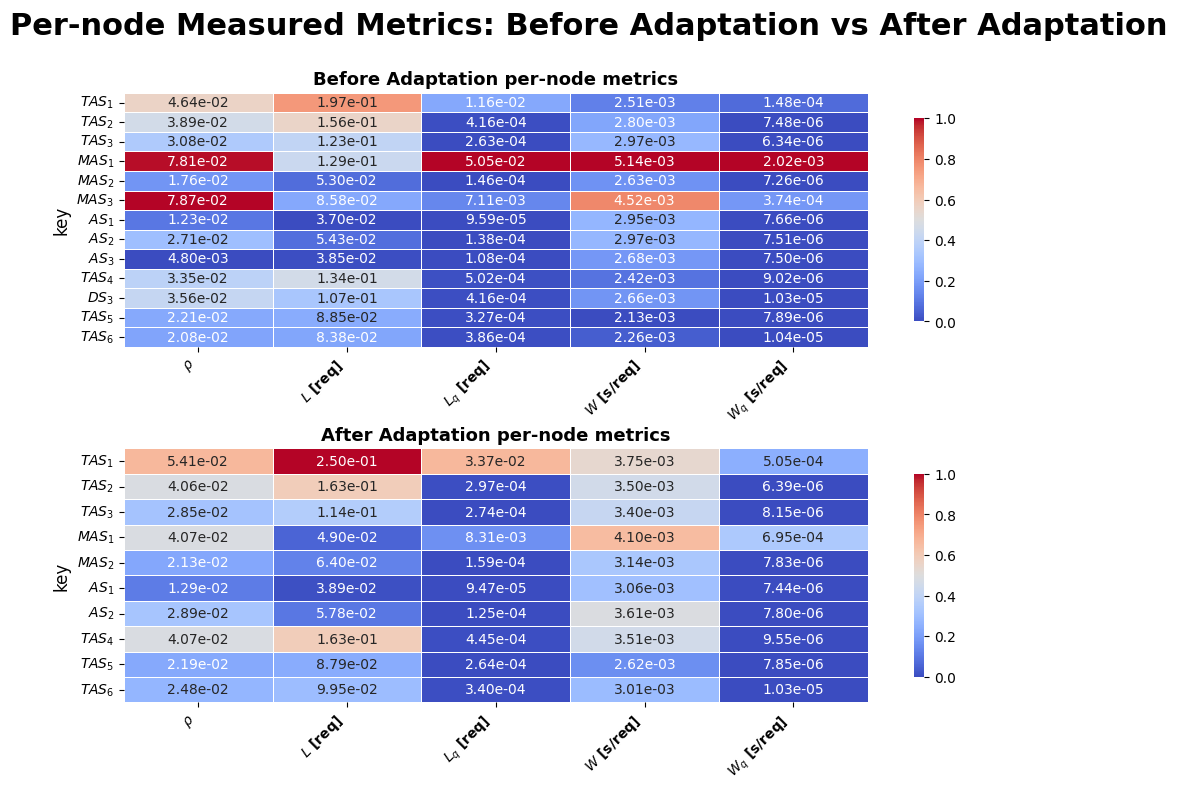

In [6]:
_node_keys = _nodes["baseline"]["key"].tolist()
_heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
_heat_labels = [
    r"$\rho$",
    r"$L$ [req]",
    r"$L_q$ [req]",
    r"$W$ [s/req]",
    r"$W_q$ [s/req]",
]

for _a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[_nodes["baseline"], _nodes[_a]],
        names=[_DISPLAY["baseline"], _DISPLAY[_a]],
        nodes=_node_keys,
        metrics=_heat_metrics,
        labels=_heat_labels,
        title=f"Per-node Measured Metrics: {_DISPLAY['baseline']} vs {_DISPLAY[_a]}",
        file_path=str(_IMG_ROOT / _a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (ratio vs baseline)

Single-panel view of the per-node, per-metric ratio change between the measured baseline and each measured adaptation. Centred diverging colour scale so positive and negative changes read as equal-intensity colours.

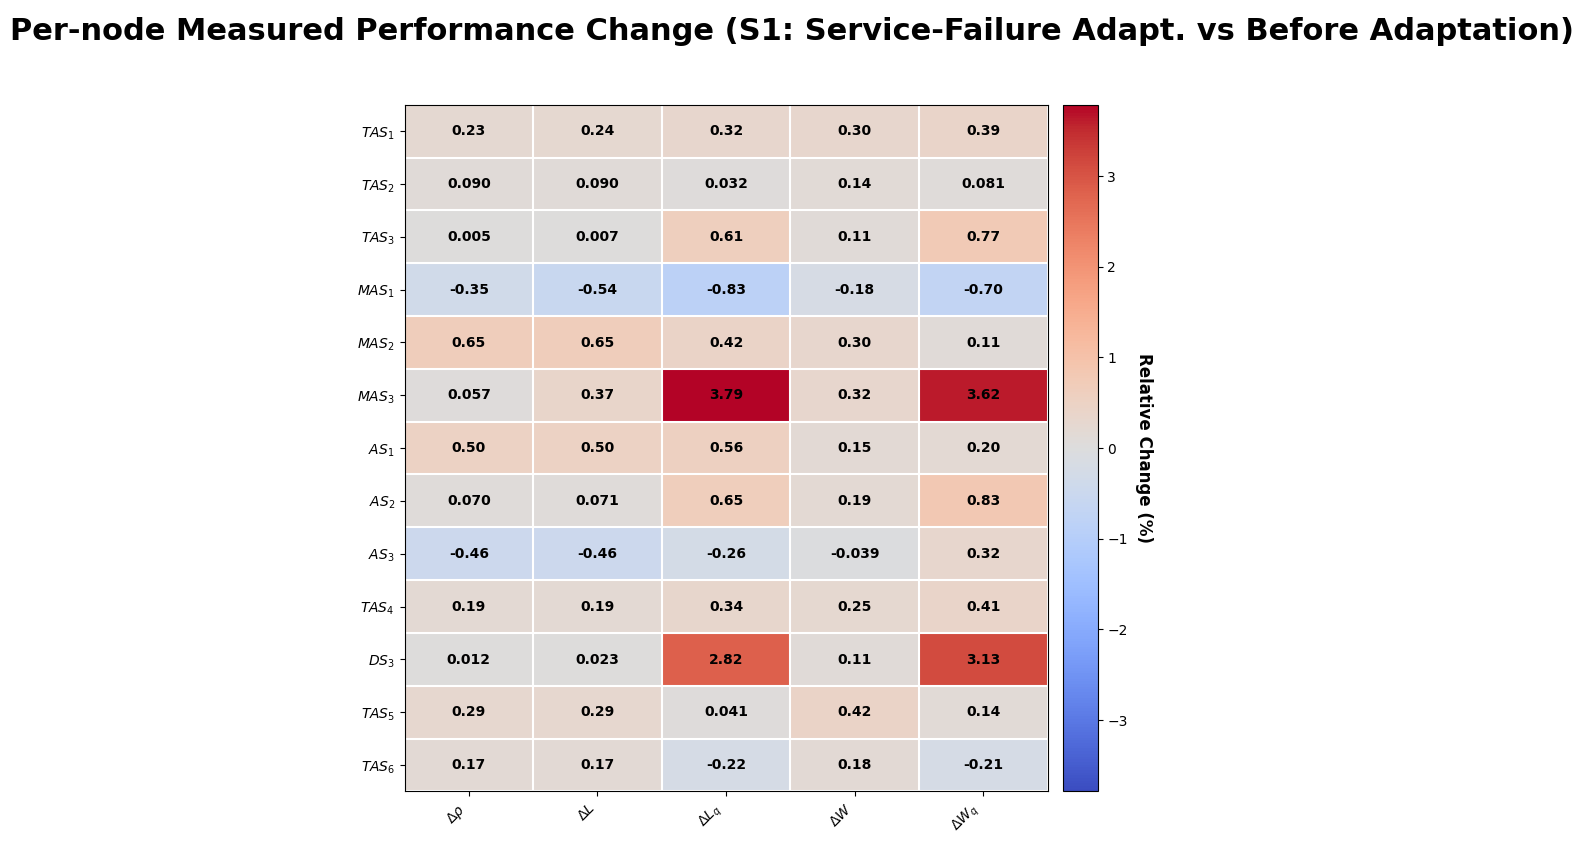

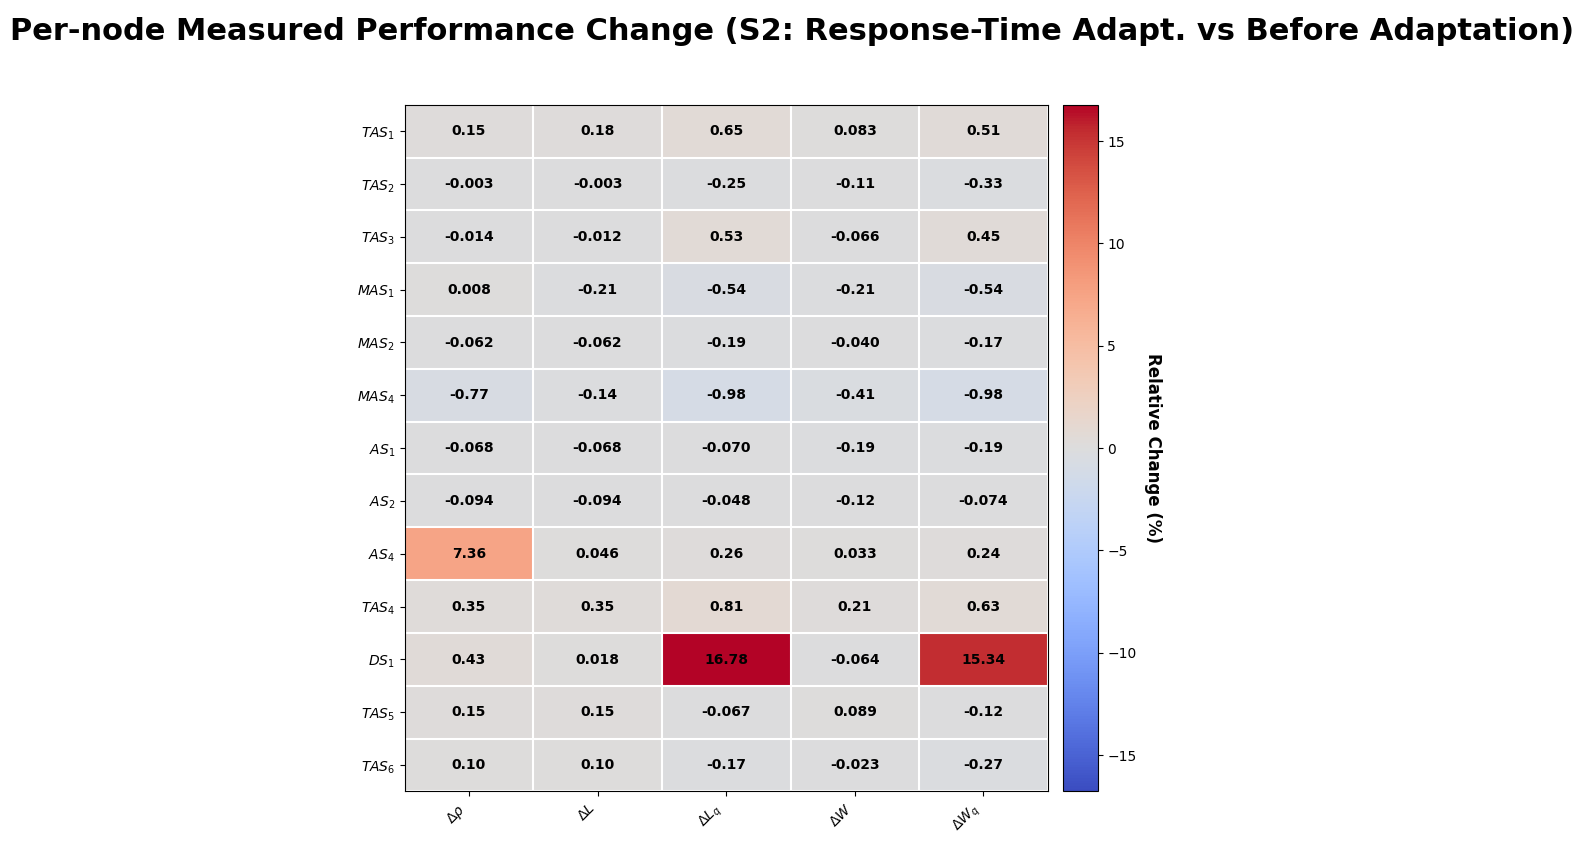

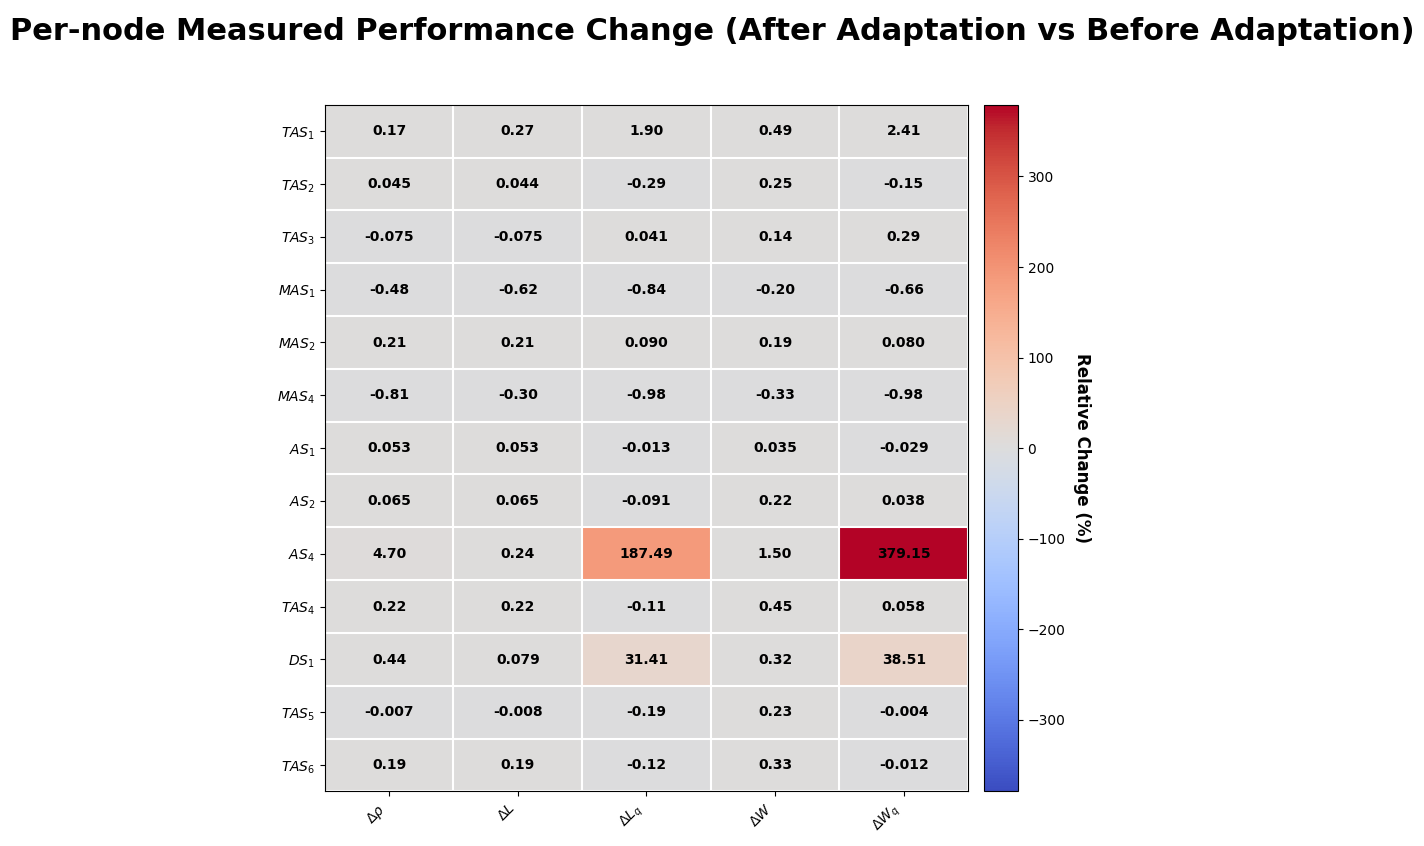

In [7]:
# mirrors the OLD convention from analytical_draft.py:
#     delta = (opti - dflt) / |dflt|     -- ratio, not percent
_diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
_diff_labels = [
    r"$\Delta \rho$",
    r"$\Delta L$",
    r"$\Delta L_q$",
    r"$\Delta W$",
    r"$\Delta W_q$",
]

_bl_nodes = _nodes["baseline"]
for _a in ["s1", "s2", "aggregate"]:
    _ac_nodes = _nodes[_a]
    _rows = []
    # align by positional index (slot) since `key` may differ at swap slots
    for _i in range(len(_ac_nodes)):
        _b_row = _bl_nodes.iloc[_i]
        _c_row = _ac_nodes.iloc[_i]
        _row = {"key": _c_row["key"]}
        for _m in _diff_metrics:
            _b, _c = float(_b_row[_m]), float(_c_row[_m])
            if _b:
                _row[_m] = (_c - _b) / abs(_b)
            else:
                _row[_m] = 0.0
        _rows.append(_row)
    _deltas = pd.DataFrame(_rows)

    plot_node_diffmap(
        deltas=_deltas,
        nodes=_deltas["key"].tolist(),
        metrics=_diff_metrics,
        labels=_diff_labels,
        title=f"Per-node Measured Performance Change ({_DISPLAY[_a]} vs {_DISPLAY['baseline']})",
        file_path=str(_IMG_ROOT / _a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the measured metrics that drive the R1 / R2 / R3 verdicts. Y-axis is log-scaled because the metrics span several orders of magnitude (W in seconds vs L in requests).

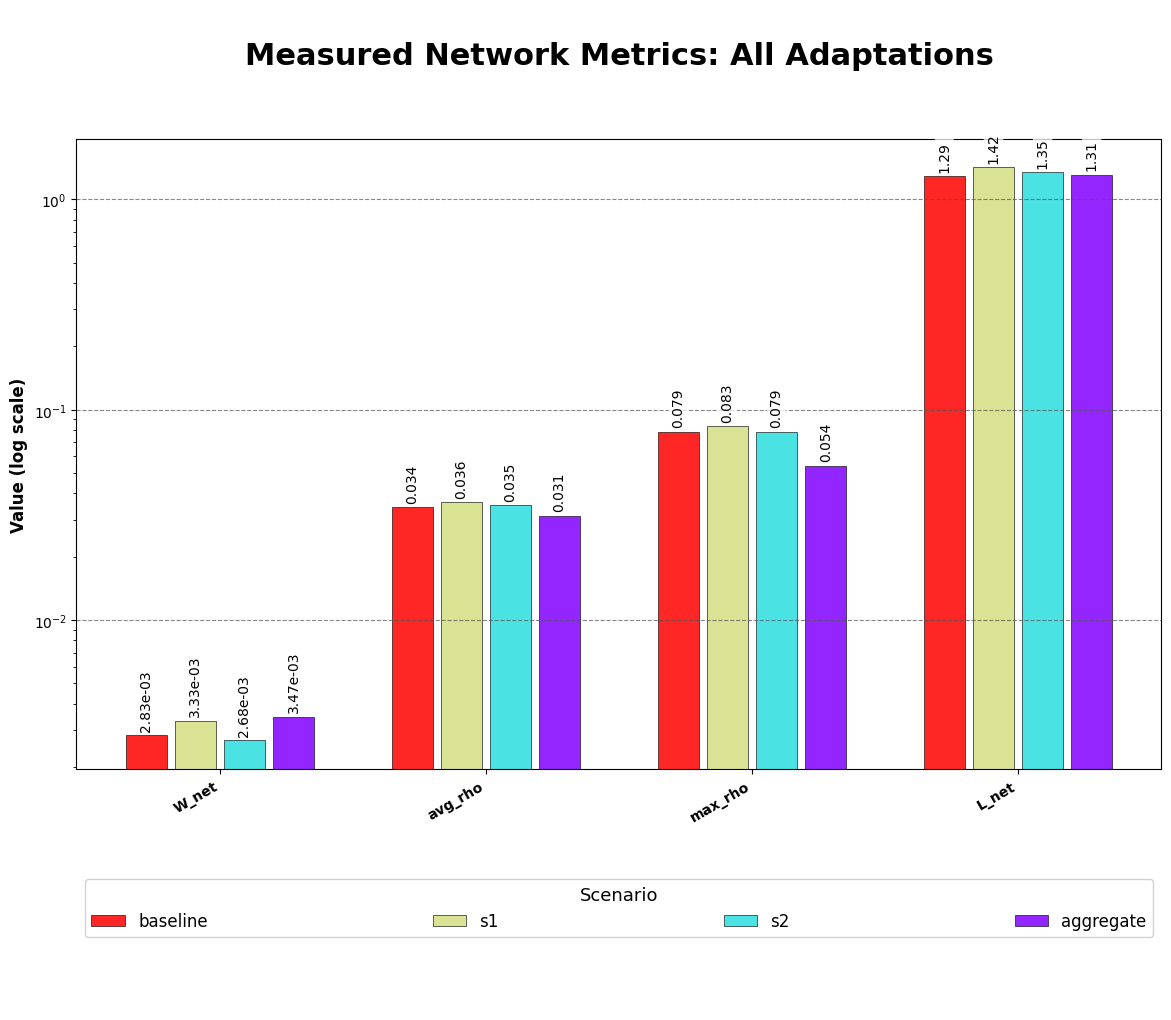

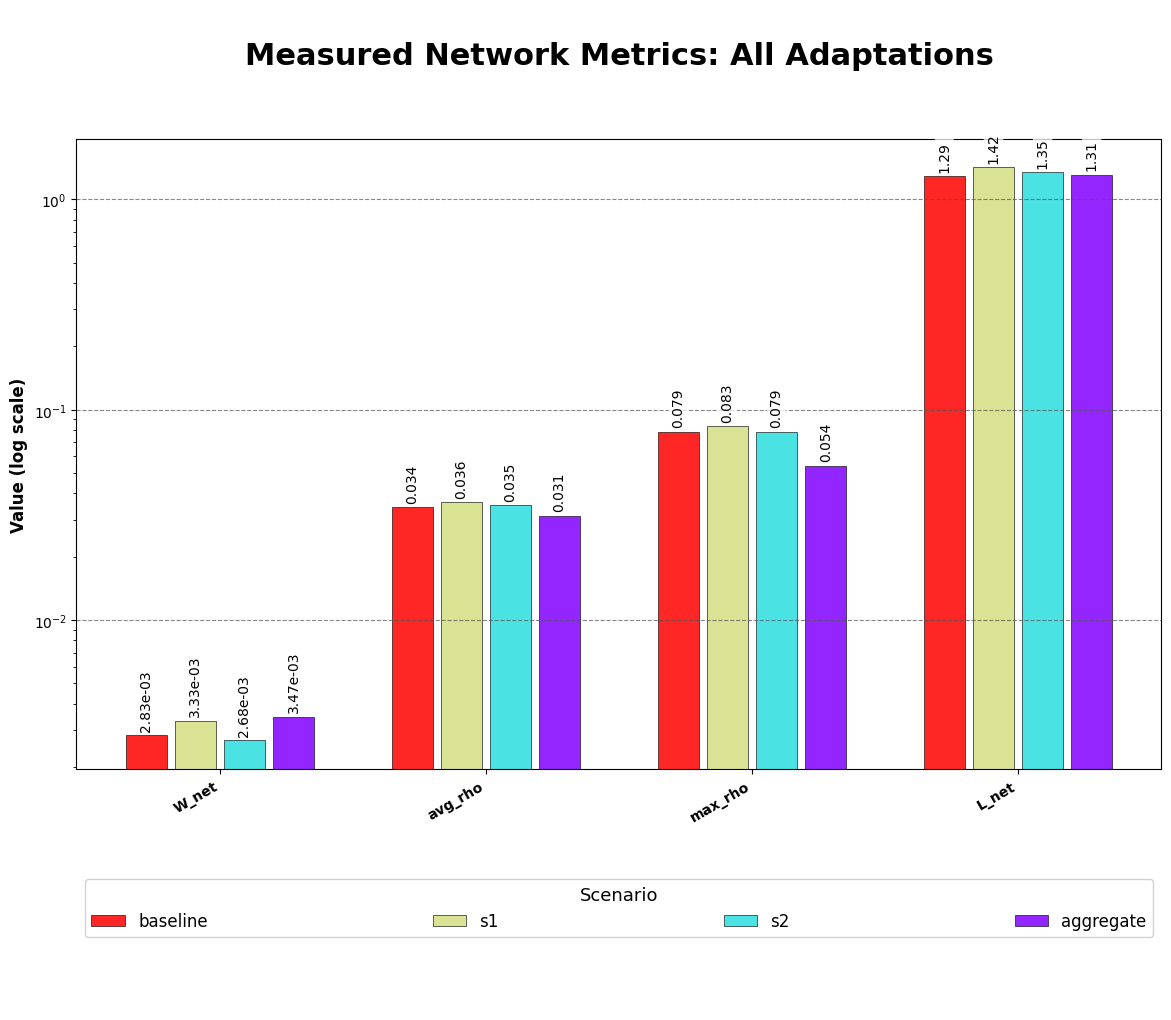

In [8]:
_bar_metrics = ["W_net", "avg_rho", "max_rho", "L_net"]

plot_arch_bars(
    nets=[_nets[_a] for _a in _ADAPTATIONS],
    names=_ADAPTATIONS,
    metrics=_bar_metrics,
    title="Measured Network Metrics: All Adaptations",
    file_path=str(_IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 7. Network-wide delta (% change vs baseline)

For every non-baseline adaptation: fractional change on the measured headline metrics. Neutral colour palette (blue = decrease, orange = increase); domain context decides whether a direction is desirable.

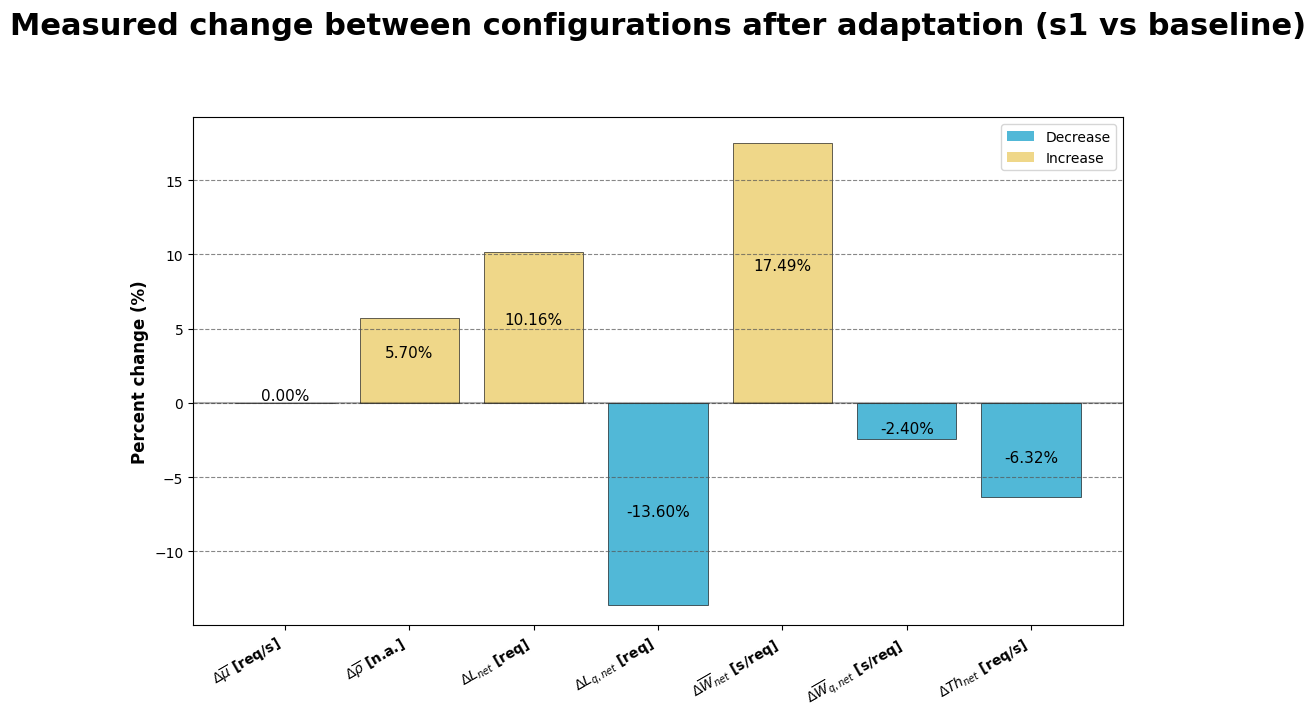

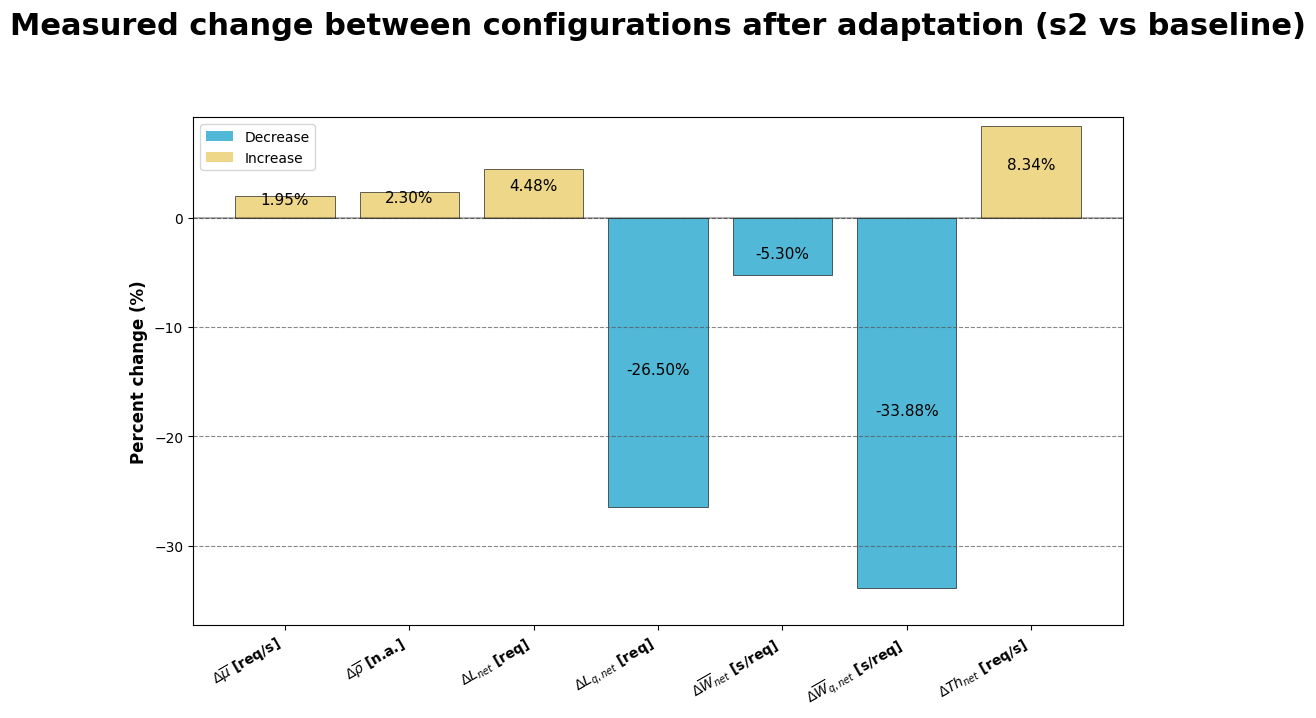

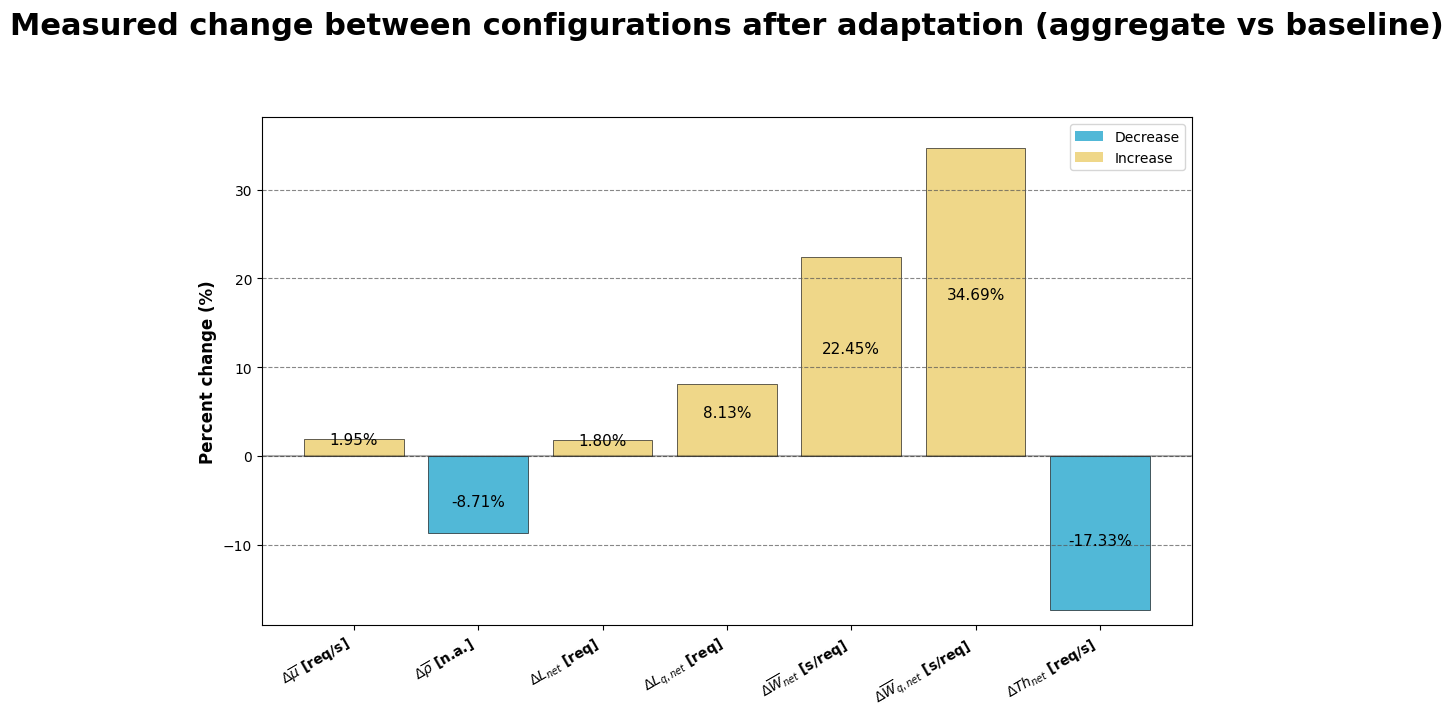

In [9]:
_delta_metrics = [
    "avg_mu",
    "avg_rho",
    "L_net",
    "Lq_net",
    "W_net",
    "Wq_net",
    "total_throughput",
]

_delta_labels = [
    r"$\Delta \overline{\mu}$ [req/s]",
    r"$\Delta \overline{\rho}$ [n.a.]",
    r"$\Delta L_{net}$ [req]",
    r"$\Delta L_{q,net}$ [req]",
    r"$\Delta \overline{W}_{net}$ [s/req]",
    r"$\Delta \overline{W}_{q,net}$ [s/req]",
    r"$\Delta Th_{net}$ [req/s]",
]

_bl = _nets["baseline"].iloc[0]
for _a in ["s1", "s2", "aggregate"]:
    _ac = _nets[_a].iloc[0]
    _row = {}
    for _m in _delta_metrics:
        if _bl[_m]:
            _row[_m] = (_ac[_m] - _bl[_m]) / _bl[_m]
        else:
            _row[_m] = 0.0
    plot_arch_delta(
        deltas=pd.DataFrame([_row]),
        metrics=_delta_metrics,
        labels=_delta_labels,
        title=f"Measured change between configurations after adaptation ({_a} vs baseline)",
        file_path=str(_IMG_ROOT / _a),
        fname="net_delta_vs_baseline.png")

## 8. R1 / R2 / R3 verdict table

Measured failure rate / response time against the thresholds in
[`data/reference/baseline.json`](data/reference/baseline.json):

- **R1** Availability: `fail_rate <= 0.03 %` (fraction `0.0003`)
- **R2** Performance: `resp_time <= 26 ms`
- **R3** Minimise `cost` subject to `R1 and R2`

`R3` has no numeric threshold; it passes whenever both `R1` and `R2` do.

In [10]:
_req_rows = []
for _a in _ADAPTATIONS:
    _r = _reqs[_a]
    _req_rows.append({
        "adaptation": _a,
        "R1 fail_rate": _r["R1"]["value"],
        "R1 pass": _r["R1"]["pass"],
        "R2 resp_time (s)": _r["R2"]["value"],
        "R2 pass": _r["R2"]["pass"],
        "R3 pass": _r["R3"]["pass"],
    })
pd.DataFrame(_req_rows).set_index("adaptation")

,R1 fail_rate,R1 pass,R2 resp_time (s),R2 pass,R3 pass
adaptation,,,,,
baseline,0.098585,False,0.002830,True,False
s1,0.095637,False,0.003325,True,False
s2,0.089870,False,0.002680,True,False
aggregate,0.101375,False,0.003466,True,False


## Summary

This notebook captures the **measured behaviour** of the FastAPI prototype across the four adaptations at their seeded operating points. Every figure under `data/img/experiment/<adp>/*.png` plus every `data/results/experiment/<adp>/<profile>.json` envelope is regenerable by a `Run All` of this notebook (or by the equivalent CLI loop).

**Cross-method comparisons** (analytic / dimensional / stochastic vs experiment, deltas, R1 / R2 / R3 reconciliation across methods) live in `07-comparison.ipynb`. The configuration-sweep view (yoly cloud across `(mu_factor, c, K)` measured on the prototype) lives in `06-yoly-experimental.ipynb`.

The experiment does NOT match the Weyns & Calinescu 2015 published numbers and is not supposed to; different technology, different absolute overheads. The headline claim is DASA's **technology-agnosticism**: the dimensionless coefficients DASA computes characterise the *architecture*, not the *implementation*, and that claim is verified downstream in `07-comparison.ipynb`.